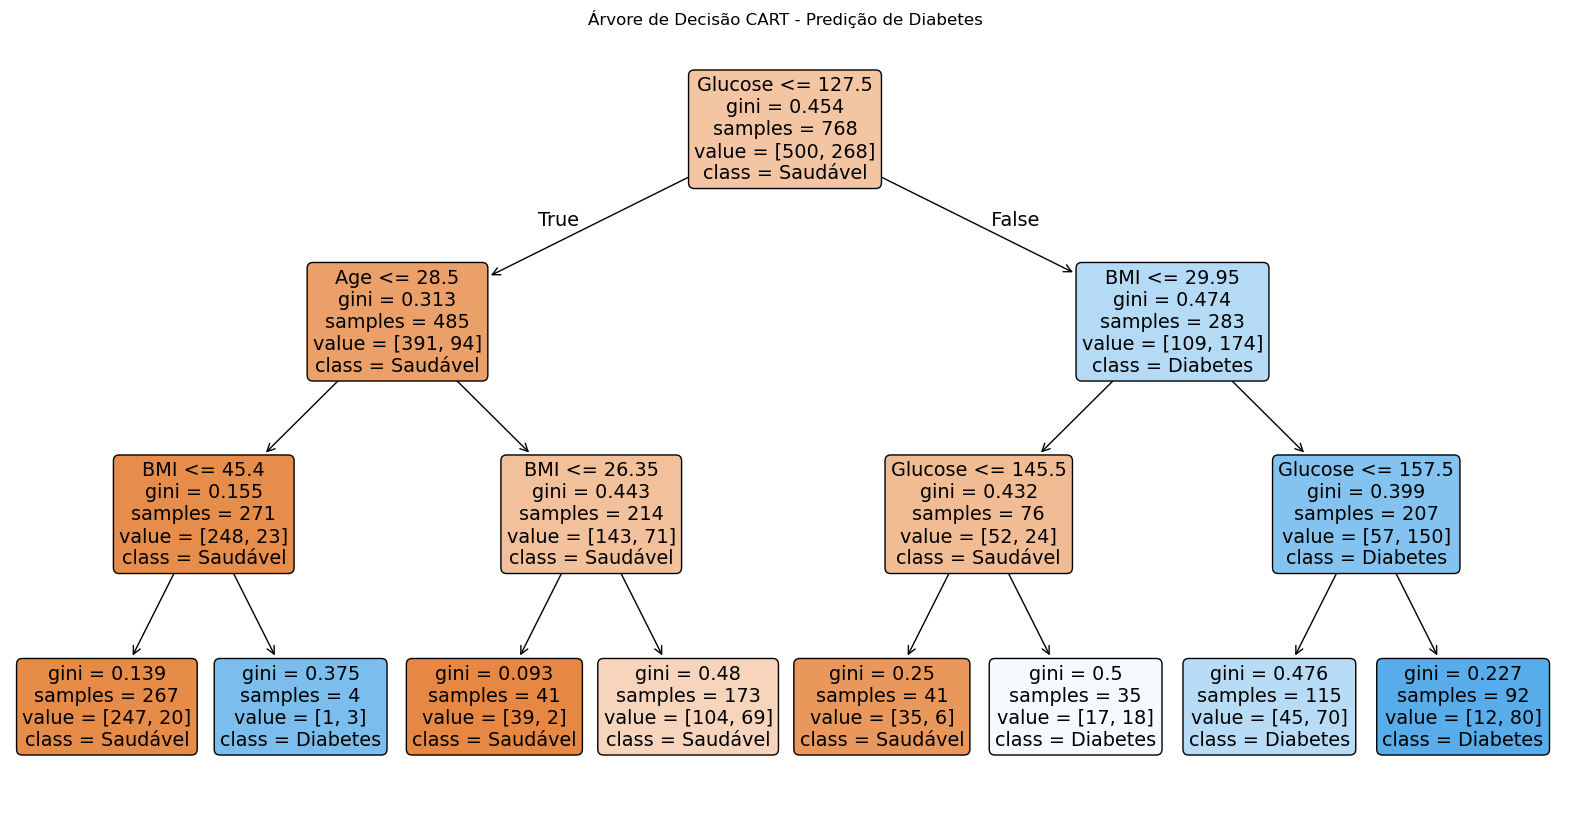

Base de Regras (CART - Diabetes):

|--- Glucose <= 127.50
|   |--- Age <= 28.50
|   |   |--- BMI <= 45.40
|   |   |   |--- class: 0
|   |   |--- BMI >  45.40
|   |   |   |--- class: 1
|   |--- Age >  28.50
|   |   |--- BMI <= 26.35
|   |   |   |--- class: 0
|   |   |--- BMI >  26.35
|   |   |   |--- class: 0
|--- Glucose >  127.50
|   |--- BMI <= 29.95
|   |   |--- Glucose <= 145.50
|   |   |   |--- class: 0
|   |   |--- Glucose >  145.50
|   |   |   |--- class: 1
|   |--- BMI >  29.95
|   |   |--- Glucose <= 157.50
|   |   |   |--- class: 1
|   |   |--- Glucose >  157.50
|   |   |   |--- class: 1



In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
import matplotlib.pyplot as plt

df_diabetes = pd.read_csv('diabetes.csv')

X = df_diabetes.drop('Outcome', axis=1)
y = df_diabetes['Outcome']

# CRIAÇÃO DO MODELO CART
model_cart_diabetes = DecisionTreeClassifier(criterion='gini', max_depth=3)
model_cart_diabetes.fit(X, y)

# VISUALIZAÇÃO 

# Gerar a imagem da Árvore
plt.figure(figsize=(20,10))
plot_tree(model_cart_diabetes, 
          feature_names=X.columns, 
          class_names=['Saudável', 'Diabetes'], 
          filled=True, 
          rounded=True)
plt.title("Árvore de Decisão CART - Predição de Diabetes")
plt.show()

# Gerar a Base de Conhecimento (Regras em texto)
regras_diabetes = export_text(model_cart_diabetes, feature_names=list(X.columns))
print("Base de Regras (CART - Diabetes):\n")
print(regras_diabetes)